# 08 — Time Series
**Goal:** Work with temporal data — the most common data type in digital analytics.

Topics:
- `resample()` — aggregate by time period (daily → weekly → monthly)
- `rolling()` — moving averages and rolling stats
- `shift()` — compare to previous periods (WoW, MoM)
- `diff()` — absolute change between periods
- Date arithmetic
- Handling gaps and missing dates

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

# Daily totals
daily = df.groupby('date').agg(
    visits      = ('visita_landing',     'sum'),
    activations = ('activacion_tarjeta',  'sum'),
).reset_index()
daily['cvr'] = daily['activations'] / daily['visits'] * 100

# Set date as index — required for resample() and rolling()
daily = daily.set_index('date')

print(daily.shape)
daily.head()

(90, 3)


,visits,activations,cvr
date,,,
2024-01-01,3097,69,2.227963
2024-01-02,2851,64,2.244826
2024-01-03,2978,65,2.182673
2024-01-04,2845,61,2.144112
2024-01-05,2914,64,2.196294


## 1. `resample()` — change time granularity
Like `groupby` but for time periods.

In [2]:
# Daily → Weekly (sum)
# 'W' = week ending Sunday, 'W-MON' = week ending Monday
weekly = daily.resample('W').agg(
    visits      = ('visits',      'sum'),
    activations = ('activations', 'sum'),
)
weekly['cvr'] = weekly['activations'] / weekly['visits'] * 100
print('Weekly:')
print(weekly.round(2))

Weekly:
            visits  activations   cvr
date                                 
2024-01-07   19804          433  2.19
2024-01-14   20490          453  2.21
2024-01-21   20833          458  2.20
2024-01-28   21227          473  2.23
2024-02-04   21224          472  2.22
2024-02-11   21611          478  2.21
2024-02-18   22465          499  2.22
2024-02-25   23445          524  2.24
2024-03-03   22187          496  2.24
2024-03-10   22911          512  2.23
2024-03-17   23131          514  2.22
2024-03-24   24314          547  2.25
2024-03-31   21132          478  2.26


In [3]:
# Daily → Monthly
monthly = daily.resample('ME').agg(   # 'ME' = month end
    visits      = ('visits',      'sum'),
    activations = ('activations', 'sum'),
    avg_cvr     = ('cvr',        'mean'),
)
monthly['true_cvr'] = monthly['activations'] / monthly['visits'] * 100
print('Monthly:')
print(monthly.round(2))

Monthly:
            visits  activations  avg_cvr  true_cvr
date                                              
2024-01-31   91825         2028     2.21      2.21
2024-02-29   92359         2056     2.22      2.23
2024-03-31  100590         2253     2.24      2.24


In [4]:
# Resample frequency aliases:
# 'D'  = daily
# 'W'  = weekly (Sunday)
# 'ME' = month end
# 'MS' = month start
# 'QE' = quarter end
# 'YE' = year end

## 2. `rolling()` — moving window statistics

In [5]:
# 7-day rolling mean — smooths out weekly noise
daily['cvr_7d']  = daily['cvr'].rolling(7).mean()
daily['cvr_14d'] = daily['cvr'].rolling(14).mean()

# center=True centers the window — better for visualization
daily['cvr_7d_centered'] = daily['cvr'].rolling(7, center=True).mean()

# Rolling std — how volatile is CVR?
daily['cvr_std_7d'] = daily['cvr'].rolling(7).std()

print(daily[['cvr','cvr_7d','cvr_14d','cvr_std_7d']].head(20).round(3))

              cvr  cvr_7d  cvr_14d  cvr_std_7d
date                                          
2024-01-01  2.228     NaN      NaN         NaN
2024-01-02  2.245     NaN      NaN         NaN
2024-01-03  2.183     NaN      NaN         NaN
2024-01-04  2.144     NaN      NaN         NaN
2024-01-05  2.196     NaN      NaN         NaN
2024-01-06  2.183     NaN      NaN         NaN
2024-01-07  2.114   2.185      NaN       0.045
2024-01-08  2.230   2.185      NaN       0.046
2024-01-09  2.144   2.171      NaN       0.039
2024-01-10  2.235   2.178      NaN       0.046
2024-01-11  2.263   2.195      NaN       0.053
2024-01-12  2.243   2.202      NaN       0.056
2024-01-13  2.164   2.199      NaN       0.057
2024-01-14  2.175   2.208    2.196       0.046
2024-01-15  2.209   2.205    2.195       0.045
2024-01-16  2.195   2.212    2.191       0.037
2024-01-17  2.177   2.204    2.191       0.037
2024-01-18  2.234   2.199    2.197       0.031
2024-01-19  2.214   2.195    2.199       0.025
2024-01-20  2

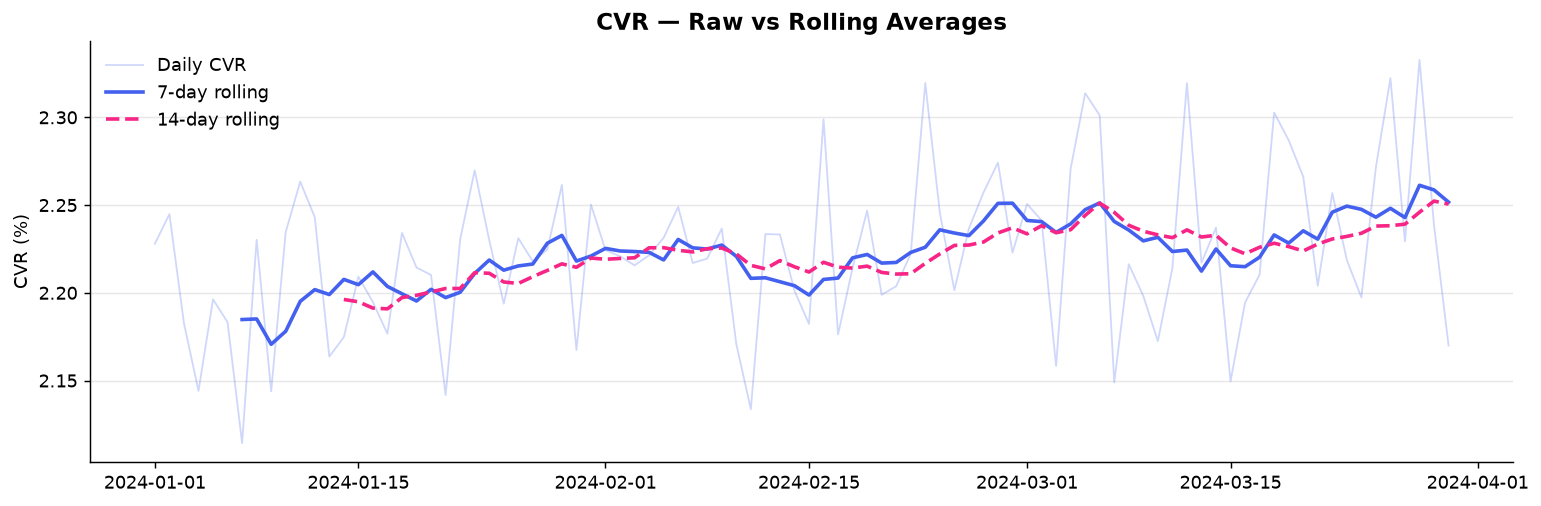

In [6]:
# Visualize raw vs smoothed
fig, ax = plt.subplots(figsize=(12, 4), dpi=130)

ax.plot(daily.index, daily['cvr'],     color='#4361ee', alpha=0.25, linewidth=1, label='Daily CVR')
ax.plot(daily.index, daily['cvr_7d'],  color='#4361ee', linewidth=2,   label='7-day rolling')
ax.plot(daily.index, daily['cvr_14d'], color='#f72585', linewidth=2, linestyle='--', label='14-day rolling')

ax.set_title('CVR — Raw vs Rolling Averages', fontsize=13, fontweight='bold')
ax.set_ylabel('CVR (%)')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8')
plt.tight_layout()
plt.show()

## 3. `shift()` — compare to previous period (WoW, MoM)

In [7]:
# shift(1) = value from 1 period ago (yesterday)
# shift(7) = value from 7 periods ago (same day last week)

daily['activations_yesterday'] = daily['activations'].shift(1)
daily['activations_last_week'] = daily['activations'].shift(7)

# Day-over-day change
daily['dod_change']  = daily['activations'] - daily['activations_yesterday']
daily['dod_pct']     = daily['dod_change'] / daily['activations_yesterday'] * 100

# Week-over-week change
daily['wow_change']  = daily['activations'] - daily['activations_last_week']
daily['wow_pct']     = daily['wow_change'] / daily['activations_last_week'] * 100

print(daily[['activations','dod_pct','wow_pct']].dropna().head(14).round(1))

            activations  dod_pct  wow_pct
date                                     
2024-01-08           68     25.9     -1.4
2024-01-09           62     -8.8     -3.1
2024-01-10           68      9.7      4.6
2024-01-11           77     13.2     26.2
2024-01-12           67    -13.0      4.7
2024-01-13           55    -17.9     -1.8
2024-01-14           56      1.8      3.7
2024-01-15           68     21.4      0.0
2024-01-16           69      1.5     11.3
2024-01-17           69      0.0      1.5
2024-01-18           71      2.9     -7.8
2024-01-19           69     -2.8      3.0
2024-01-20           57    -17.4      3.6
2024-01-21           55     -3.5     -1.8


In [8]:
# Month-over-month using monthly resample
monthly['activations_prev_month'] = monthly['activations'].shift(1)
monthly['mom_pct'] = (
    (monthly['activations'] - monthly['activations_prev_month'])
    / monthly['activations_prev_month'] * 100
)

print(monthly[['activations','activations_prev_month','mom_pct']].round(1))

            activations  activations_prev_month  mom_pct
date                                                    
2024-01-31         2028                     NaN      NaN
2024-02-29         2056                  2028.0      1.4
2024-03-31         2253                  2056.0      9.6


## 4. `diff()` — absolute change between periods

In [9]:
# diff(1) = current - previous
# diff(7) = current - same day last week
daily['activations_diff_7d'] = daily['activations'].diff(7)

print(daily[['activations','activations_diff_7d']].dropna().head(10))

            activations  activations_diff_7d
date                                        
2024-01-08           68                 -1.0
2024-01-09           62                 -2.0
2024-01-10           68                  3.0
2024-01-11           77                 16.0
2024-01-12           67                  3.0
2024-01-13           55                 -1.0
2024-01-14           56                  2.0
2024-01-15           68                  0.0
2024-01-16           69                  7.0
2024-01-17           69                  1.0


## 5. Handling missing dates — filling gaps

In [10]:
# Sometimes exports skip dates (weekends, holidays)
# Create a complete date range and reindex

df_with_gap = daily.copy().drop(index=pd.Timestamp('2024-01-15'))  # simulate a gap

# Create a complete date range
full_range = pd.date_range(df_with_gap.index.min(), df_with_gap.index.max(), freq='D')

# Reindex — inserts NaN for missing dates
df_complete = df_with_gap.reindex(full_range)

print('Rows before reindex:', len(df_with_gap))
print('Rows after reindex: ', len(df_complete))
print('Missing date row:')
print(df_complete.loc['2024-01-14':'2024-01-16', ['visits','activations']])

Rows before reindex: 89
Rows after reindex:  90
Missing date row:
            visits  activations
2024-01-14  2575.0         56.0
2024-01-15     NaN          NaN
2024-01-16  3144.0         69.0


In [11]:
# Fill the gap — forward fill from the previous day
df_complete['visits']      = df_complete['visits'].ffill()
df_complete['activations'] = df_complete['activations'].ffill()

print(df_complete.loc['2024-01-14':'2024-01-16', ['visits','activations']])

            visits  activations
2024-01-14  2575.0         56.0
2024-01-15  2575.0         56.0
2024-01-16  3144.0         69.0


## Summary
| Tool | Use when |
|---|---|
| `df.set_index('date')` | Required before resample/rolling |
| `resample('W').agg(...)` | Aggregate daily data to weekly/monthly |
| `rolling(7).mean()` | 7-day moving average |
| `rolling(7, center=True)` | Centered window — better for charts |
| `shift(1)` | Yesterday's value |
| `shift(7)` | Same day last week (WoW) |
| `diff(7)` | Absolute change vs 7 days ago |
| `reindex(full_range)` | Fill in missing dates |
| `ffill()` | Forward fill missing values |

**Next:** `09_etl_real_world.ipynb` — full end-to-end pipeline: raw Adobe + paid CSVs → clean unified table → charts.